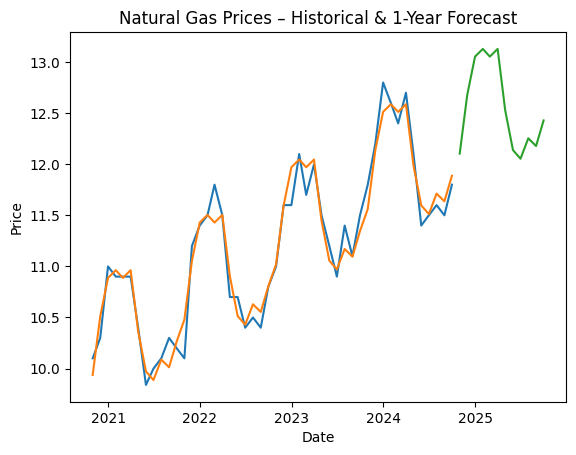

Price on 2023-06-15: 11.01
Price on 2025-05-20: 12.28


In [ ]:
# ============================================================
# Natural Gas Price Modeling & 1-Year Forecast
# Task 1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ------------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ------------------------------------------------------------

file_path = "Nat_Gas(1).csv"   # ensure file is in same directory
df = pd.read_csv(file_path)

# Convert date column and clean
df["Dates"] = pd.to_datetime(
    df["Dates"],
    format="%m/%d/%y"
)
df = df.sort_values("Dates")
df.set_index("Dates", inplace=True)

# Rename price column for clarity
df.rename(columns={"Prices": "Price"}, inplace=True)

# ------------------------------------------------------------
# 2. FEATURE ENGINEERING
# ------------------------------------------------------------

# Create time index for trend modeling
df["time_index"] = np.arange(len(df))

# Extract month for seasonality
df["month"] = df.index.month

# Create monthly dummy variables (seasonal effects)
month_dummies = pd.get_dummies(df["month"], prefix="month", drop_first=True)

# Define independent (X) and dependent (y) variables
X = pd.concat([df["time_index"], month_dummies], axis=1)
y = df["Price"]

# ------------------------------------------------------------
# 3. MODEL FITTING (Trend + Seasonality)
# ------------------------------------------------------------

model = LinearRegression()
model.fit(X, y)

# Generate fitted historical values
df["fitted_price"] = model.predict(X)

# ------------------------------------------------------------
# 4. FORECAST NEXT 12 MONTHS
# ------------------------------------------------------------

future_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthEnd(),
    periods=12,
    freq="ME"
)

future_df = pd.DataFrame(index=future_dates)

# Create future features
future_df["time_index"] = np.arange(len(df), len(df) + 12)
future_df["month"] = future_df.index.month

future_month_dummies = pd.get_dummies(future_df["month"], prefix="month")

# Align columns with training data
future_month_dummies = future_month_dummies.reindex(
    columns=month_dummies.columns,
    fill_value=0
)

X_future = pd.concat([future_df["time_index"], future_month_dummies], axis=1)

# Predict future prices
future_df["predicted_price"] = model.predict(X_future)

# ------------------------------------------------------------
# 5. CREATE DAILY INTERPOLATED SERIES
# ------------------------------------------------------------

# Combine historical fitted and future predicted prices
monthly_series = pd.concat([
    df["fitted_price"],
    future_df["predicted_price"]
])

# Create full daily range
daily_index = pd.date_range(
    start=df.index[0],
    end=future_df.index[-1],
    freq="D"
)

daily_df = pd.DataFrame(index=daily_index)
daily_df["price"] = monthly_series.reindex(daily_df.index)

# Use linear interpolation for smooth daily estimates
daily_df["price"] = daily_df["price"].interpolate(method="linear")

# ------------------------------------------------------------
# 6. PRICE QUERY FUNCTION
# ------------------------------------------------------------

def get_gas_price(input_date):
    """
    Returns estimated natural gas price for a given date.
    
    Parameters:
        input_date (str or datetime): Date to query
        
    Returns:
        float: Estimated gas price
    """
    input_date = pd.to_datetime(input_date)

    if input_date < daily_df.index[0] or input_date > daily_df.index[-1]:
        return "Date outside model range"

    return round(float(daily_df.loc[input_date]["price"]),2)

# ------------------------------------------------------------
# 7. VISUALIZATION
# ------------------------------------------------------------

plt.figure()
plt.plot(df.index, df["Price"])
plt.plot(df.index, df["fitted_price"])
plt.plot(future_df.index, future_df["predicted_price"])
plt.title("Natural Gas Prices – Historical & 1-Year Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# ------------------------------------------------------------
# 8. EXAMPLE USAGE
# ------------------------------------------------------------

print("Price on 2023-06-15:", get_gas_price("2023-06-15"))
print("Price on 2025-05-20:", get_gas_price("2025-05-20"))